In [1]:
!pip install -q venn-abers && pip install -q cir-model

  Preparing metadata (setup.py) ... done


In [2]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from venn_abers import VennAbersCalibrator
from cir_model import CenteredIsotonicRegression

from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.linear_model import (
                LogisticRegression, LogisticRegressionCV, LinearRegression,
                Ridge, RidgeCV, Lasso, LassoCV, ElasticNetCV, BayesianRidge
)

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, r2_score, PredictionErrorDisplay

from tqdm.notebook import tqdm
from time import time
import warnings

## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
SEED = 42
tf.keras.utils.set_random_seed(SEED)

GREEN  = '\033[32m'
YELLOW = '\033[33m'
RESET  = '\033[0m'

print(f"CLASSIC {GREEN} GREEN {RESET} {YELLOW} YELLOW {RESET}")

2026-03-06 23:15:07.623231: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772838907.891568      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772838907.978536      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772838908.701486      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772838908.701543      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772838908.701547      17 computation_placer.cc:177] computation placer alr

CLASSIC  GREEN   YELLOW 


# 1.__LOAD DATA

In [3]:
PATH   = '/kaggle/input/competitions/playground-series-s6e2/'

train  = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
TARGET = train.columns[-1]

train[TARGET] = train[TARGET].map({'Presence': 1, 'Absence': 0})

submit = pd.read_csv(PATH+'sample_submission.csv')
y_true = train[TARGET].to_numpy()

print(f"✓ DATA LOAD COMPLETE!")

✓ DATA LOAD COMPLETE!


In [4]:
## -- Append predicted columns as extra features --
## -- os.walk: Deep search with subfolders --
def dataloader(filepath, train_prefix, test_prefix):    
    train_df = pd.DataFrame()
    test_df = pd.DataFrame()
    
    print('Loading .npy files: ', end='')
    for (root, dirs, files) in os.walk(filepath):
        for i, file in enumerate(sorted(files), 1):
            if i%10 == 0: print(f'{i}%.. ', end='')
            if file.endswith('.npy') and train_prefix in file:
                train_path = np.load(os.path.join(root, file))
                train_df = pd.concat([train_df, pd.Series(train_path, name=file[4:-4])], axis=1)
            elif file.endswith('.npy') and test_prefix in file:
                test_path = np.load(os.path.join(root, file))
                test_df = pd.concat([test_df, pd.Series(test_path, name=file[5:-4])], axis=1)
    print()

    print('Loading .parquet files: ', end='')
    for (root, dirs, files) in os.walk(filepath):
        for i, file in enumerate(sorted(files), 1):
            if i%10 == 0: print(f"{i}%.. ", end="")
            if file.endswith('.parquet') and train_prefix in file:
                train_path = os.path.join(root, file)
                train_df = pd.concat([train_df, pd.read_parquet(train_path)], axis=1)
            elif file.endswith('.parquet') and test_prefix in file:
                test_path = os.path.join(root, file)
                test_df = pd.concat([test_df, pd.read_parquet(test_path)], axis=1)
    print()
    print(f"Total oof  models: {len(train_df.columns)} || Shape: {train_df.shape}")
    print(f"Total pred models: {len(test_df.columns)} || Shape: {test_df.shape}")
    print()

    return train_df, test_df

In [5]:
def rename_duplicate_cols(df: pd.DataFrame) -> pd.DataFrame:
    original_cols = list(df.columns)
    new_cols = []
    # Track how many times we've seen each original name
    seen = {}

    for col in tqdm(original_cols, desc="Fixing columns"):
        if col not in seen:
            # First occurrence: keep name unchanged
            seen[col] = 1
            new_cols.append(col)
        else:
            # Duplicate: append suffix _k where k starts at 0
            suffix = seen[col] - 1 # 0 for first duplicate, 1 for second,
            new_name = f"{col}_{suffix}"
            new_cols.append(new_name)
            seen[col] += 1

    # Apply new column names
    df_renamed = df.copy()
    df_renamed.columns = new_cols
    print(f"{YELLOW}Columns fixed!!!{RESET}")

    return df_renamed


In [6]:
PATHS = [
    '/kaggle/input/datasets/',
]

## -- Load dataframes --
oofs = []
preds  = []

## -- Load train/test datasets --
for p in PATHS:
    tr, ts = dataloader(p, 'oof', 'test')
    oofs.append(tr)
    preds.append(ts)

## -- Concat datasets --
oof_df = pd.concat(oofs, axis=1)
pred_df  = pd.concat(preds, axis=1)

print('OOF/TEST shape:', oof_df.shape, pred_df.shape)

# ## -- Drop models if necessary --
# for c in oof_df.columns:
#     if 'L2' in c or 'L3' in c: #
#         oof_df.drop([c], axis=1, inplace=True)
#         pred_df.drop([c], axis=1, inplace=True)
#     elif c == TARGET:
#         oof_df.drop([c], axis=1, inplace=True)
        
print('-'*50)

## -- Check for missingness --
print(f'Train Null values: {oof_df.isna().sum().sum()}')
print(f'Test  Null values: {pred_df.isna().sum().sum()}')

print('-'*50)

## -- Apply column rename function --
oof_df = rename_duplicate_cols(oof_df)
pred_df = rename_duplicate_cols(pred_df)

print()

display(oof_df.head(3))
print()
display(pred_df.head(3))

Loading .npy files: 10%.. 20%.. 30%.. 40%.. 50%.. 
Loading .parquet files: 10%.. 20%.. 30%.. 40%.. 50%.. 
Total oof  models: 131 || Shape: (630000, 131)
Total pred models: 131 || Shape: (270000, 131)

OOF/TEST shape: (630000, 131) (270000, 131)
--------------------------------------------------
Train Null values: 0
Test  Null values: 0
--------------------------------------------------


Fixing columns:   0%|          | 0/131 [00:00<?, ?it/s]

Columns fixed!!!


Fixing columns:   0%|          | 0/131 [00:00<?, ?it/s]

Columns fixed!!!



,pytabV1_realMLP_955522,pytabV1_realMLP_955665,pytabV1_tabM_955693,pytabV2nn_mlpPLR_954599,pytabV2nn_realMLP_955483,pytabV2nn_tabM_955677,BARTZv1w_42_953596,BARTZv1w_777_953514,BARTZv1w_1234_95352,BARTZv1w_24611_953578,BARTZv1w_0_953541,CAT_plain_v1BAYES_42_955707,CAT_plain_v1BERN_42_955477,CAT_plain_v1LOSS_42_955608,CAT_order_v1BAYES_42_955717,CAT_plain_v2BAYES_777_955702,CAT_plain_v2BERN_777_955469,CAT_plain_v2LOSS_777_955598,CAT_order_v2BAYES_777_955709,CAT_plain_v3BAYES_24611_955704,HISTv1_42_955525,HISTv1_777_955536,HISTv1_1234_955527,HISTv1_24611_955512,HISTv1_0_955518,LGBv1BAG_31_005_42_955677,LGBv1BAG_31_005_777_955672,LGBv1BAG_31_005_1234_955674,LGBv1BAG_31_005_24611_955668,LGBv1GOSS_31_005_42_955675,LGBv1GOSS_31_005_777_955671,LGBv1GOSS_31_005_1234_955673,LGBv1GOSS_31_005_24611_95567,LGBv2BAG_01_42_955676,LGBv2BAG_777_955682,LGBv2BAG_1234_955676,LGBv2BAG_24611_955679,LGBv2BAG_0_955683,LGBv2GOSS_01_42_955679,LGBv2GOSS_777_955683,LGBv2GOSS_1234_955677,LGBv2GOSS_24611_955678,LGBv2GOSS_0_955685,LGBv3BAG_01_42_955669,LGBv3BAG_777_955678,LGBv3BAG_1234_955679,LGBv3BAG_24611_955674,LGBv3BAG_0_95568,LGBv3GOSS_01_42_955714,LGBv3GOSS_777_955723,LGBv3GOSS_1234_955714,LGBv3GOSS_24611_955717,LGBv3GOSS_0_955716,LGBv3_fixBAG_fix_42_955713,LGBv3_fixBAG_fix_777_955722,LGBv3_fixBAG_fix_1234_955711,LGBv3_fixBAG_fix_24611_955715,LGBv3_fixBAG_fix_0_955713,LGBv4BAG_42_955706,LGBv4BAG_777_9557,LGBv4BAG_1234_955706,LGBv4BAG_24611_955697,LGBv4BAG_0_955702,LGBv4GOSS_42_955705,LGBv4GOSS_777_955698,LGBv4GOSS_1234_955707,LGBv4GOSS_24611_955699,LGBv4GOSS_0_955698,LGBv5BAG_42_955684,LGBv5BAG_777_9557,LGBv5BAG_1234_955708,LGBv5BAG_24611_955702,LGBv5BAG_0_955702,LGBv5GOSS_42_955684,LGBv5GOSS_777_955699,LGBv5GOSS_1234_955707,LGBv5GOSS_24611_955699,LGBv5GOSS_0_955703,LOGv1_ohe_all_955517,LOGv1_ohe_all_drop_none_955526,TabNETv1_42_955091,XGBv1GBT_42_955717,XGBv1GBT_777_95572,XGBv1GBT_1234_955719,XGBv1GBT_24611_955719,XGBv1GBT_0_955717,XGBv1LOSS_4_42_955698,XGBv1LOSS_777_955698,XGBv1LOSS_1234_9557,XGBv1LOSS_24611_955696,XGBv1LOSS_0_955697,XGBv1GRAD_42_955715,XGBv1GRAD_777_95571,XGBv1GRAD_1234_955717,XGBv1GRAD_24611_955715,XGBv1GRAD_0_955717,XGBv2GBT_42_955722,XGBv2GBT_777_955723,XGBv2GBT_1234_955722,XGBv2GBT_24611_955721,XGBv2GBT_0_955722,XGBv2LOSS_4_42_955703,XGBv2LOSS_777_9557,XGBv2LOSS_1234_955702,XGBv2LOSS_24611_955698,XGBv2LOSS_0_955703,XGBv2GRAD_42_955716,XGBv2GRAD_777_955722,XGBv2GRAD_1234_955718,XGBv2GRAD_24611_955716,XGBv2GRAD_0_955715,XGBv3GBT_42_955682,XGBv3GBT_777_955682,XGBv3GBT_1234_955683,XGBv3GBT_24611_955683,XGBv3GBT_0_955677,XGBv3LOSS_42_955686,XGBv3LOSS_777_955689,XGBv3LOSS_1234_955688,XGBv3LOSS_24611_955687,XGBv3LOSS_0_955685,XLEARNv1_fm_955651,XLEARNv2_linear_955525,XLEARNv2_fm_955653,XLEARNv3_fm_95566,XLEARNv3_ffm_95552,XLEARNv3_linear_955543,YDFv1_local_42_955533,YDFv1_global_42_955533,xgb_tabM_pseudo_955705,xgb_tabM_pseudo_955718
0,0.948943,0.994271,0.997665,0.998774,0.949808,0.998040,1.024284,0.998312,1.000147,1.003344,1.008991,0.997356,0.996361,0.996653,0.997288,0.997419,0.996472,0.996869,0.997415,0.997282,0.994924,0.994925,0.994422,0.995296,0.995136,0.996346,0.996481,0.996442,0.996632,0.996300,0.996630,0.996684,0.996454,0.996810,0.997106,0.996695,0.996583,0.996408,0.996692,0.996958,0.996792,0.996849,0.996570,0.996482,0.996111,0.995996,0.996302,0.996196,0.998250,0.998192,0.998299,0.998276,0.998329,0.998264,0.998234,0.998292,0.998230,0.998280,0.998306,0.998069,0.998281,0.998064,0.998085,0.998241,0.998013,0.998254,0.998047,0.998084,0.997959,0.997986,0.997946,0.998091,0.997960,0.997982,0.998028,0.997933,0.998064,0.997901,0.998195,0.998116,0.999321,0.997869,0.997953,0.997876,0.997884,0.997901,0.997323,0.997308,0.997395,0.997420,0.997371,0.997822,0.997891,0.997963,0.997926,0.997932,0.998095,0.998058,0.998071,0.998058,0.997969,0.997447,0.997515,0.997554,0.997457,0.997463,0.998178,0.998202,0.998220,0.998164,0.998166,0.998009,0.998030,0.998101,0.997821,0.998069,0.998105,0.998197,0.998039,0.998030,0.998128,0.998406,0.998211,0.998400,0.99

,pytabV1_realMLP_955522,pytabV1_realMLP_955665,pytabV1_tabM_955693,pytabV2nn_mlpPLR_954599,pytabV2nn_realMLP_955483,pytabV2nn_tabM_955677,BARTZv1w_42_953596,BARTZv1w_777_953514,BARTZv1w_1234_95352,BARTZv1w_24611_953578,BARTZv1w_0_953541,CAT_plain_v1BAYES_42_955707,CAT_plain_v1BERN_42_955477,CAT_plain_v1LOSS_42_955608,CAT_order_v1BAYES_42_955717,CAT_plain_v2BAYES_777_955702,CAT_plain_v2BERN_777_955469,CAT_plain_v2LOSS_777_955598,CAT_order_v2BAYES_777_955709,CAT_plain_v3BAYES_24611_955704,HISTv1_42_955525,HISTv1_777_955536,HISTv1_1234_955527,HISTv1_24611_955512,HISTv1_0_955518,LGBv1BAG_31_005_42_955677,LGBv1BAG_31_005_777_955672,LGBv1BAG_31_005_1234_955674,LGBv1BAG_31_005_24611_955668,LGBv1GOSS_31_005_42_955675,LGBv1GOSS_31_005_777_955671,LGBv1GOSS_31_005_1234_955673,LGBv1GOSS_31_005_24611_95567,LGBv2BAG_01_42_955676,LGBv2BAG_777_955682,LGBv2BAG_1234_955676,LGBv2BAG_24611_955679,LGBv2BAG_0_955683,LGBv2GOSS_01_42_955679,LGBv2GOSS_777_955683,LGBv2GOSS_1234_955677,LGBv2GOSS_24611_955678,LGBv2GOSS_0_955685,LGBv3BAG_01_42_955669,LGBv3BAG_777_955678,LGBv3BAG_1234_955679,LGBv3BAG_24611_955674,LGBv3BAG_0_95568,LGBv3GOSS_01_42_955714,LGBv3GOSS_777_955723,LGBv3GOSS_1234_955714,LGBv3GOSS_24611_955717,LGBv3GOSS_0_955716,LGBv3_fixBAG_fix_42_955713,LGBv3_fixBAG_fix_777_955722,LGBv3_fixBAG_fix_1234_955711,LGBv3_fixBAG_fix_24611_955715,LGBv3_fixBAG_fix_0_955713,LGBv4BAG_42_955706,LGBv4BAG_777_9557,LGBv4BAG_1234_955706,LGBv4BAG_24611_955697,LGBv4BAG_0_955702,LGBv4GOSS_42_955705,LGBv4GOSS_777_955698,LGBv4GOSS_1234_955707,LGBv4GOSS_24611_955699,LGBv4GOSS_0_955698,LGBv5BAG_42_955684,LGBv5BAG_777_9557,LGBv5BAG_1234_955708,LGBv5BAG_24611_955702,LGBv5BAG_0_955702,LGBv5GOSS_42_955684,LGBv5GOSS_777_955699,LGBv5GOSS_1234_955707,LGBv5GOSS_24611_955699,LGBv5GOSS_0_955703,LOGv1_ohe_all_955517,LOGv1_ohe_all_drop_none_955526,TabNETv1_42_955091,XGBv1GBT_42_955717,XGBv1GBT_777_95572,XGBv1GBT_1234_955719,XGBv1GBT_24611_955719,XGBv1GBT_0_955717,XGBv1LOSS_4_42_955698,XGBv1LOSS_777_955698,XGBv1LOSS_1234_9557,XGBv1LOSS_24611_955696,XGBv1LOSS_0_955697,XGBv1GRAD_42_955715,XGBv1GRAD_777_95571,XGBv1GRAD_1234_955717,XGBv1GRAD_24611_955715,XGBv1GRAD_0_955717,XGBv2GBT_42_955722,XGBv2GBT_777_955723,XGBv2GBT_1234_955722,XGBv2GBT_24611_955721,XGBv2GBT_0_955722,XGBv2LOSS_4_42_955703,XGBv2LOSS_777_9557,XGBv2LOSS_1234_955702,XGBv2LOSS_24611_955698,XGBv2LOSS_0_955703,XGBv2GRAD_42_955716,XGBv2GRAD_777_955722,XGBv2GRAD_1234_955718,XGBv2GRAD_24611_955716,XGBv2GRAD_0_955715,XGBv3GBT_42_955682,XGBv3GBT_777_955682,XGBv3GBT_1234_955683,XGBv3GBT_24611_955683,XGBv3GBT_0_955677,XGBv3LOSS_42_955686,XGBv3LOSS_777_955689,XGBv3LOSS_1234_955688,XGBv3LOSS_24611_955687,XGBv3LOSS_0_955685,XLEARNv1_fm_955651,XLEARNv2_linear_955525,XLEARNv2_fm_955653,XLEARNv3_fm_95566,XLEARNv3_ffm_95552,XLEARNv3_linear_955543,YDFv1_local_42_955533,YDFv1_global_42_955533,xgb_tabM_pseudo_955705,xgb_tabM_pseudo_955718
0,0.902585,0.947821,0.954393,0.953737,0.900125,0.957686,0.938856,0.928100,0.932958,0.925692,0.936459,0.944083,0.951161,0.956541,0.942709,0.942919,0.951514,0.957654,0.941972,0.944004,0.956028,0.956708,0.954753,0.958349,0.949735,0.953561,0.954959,0.953434,0.953535,0.953509,0.955099,0.953605,0.952829,0.950850,0.950714,0.949169,0.948882,0.948596,0.950606,0.951389,0.949201,0.949233,0.949779,0.958578,0.956693,0.957628,0.957349,0.956037,0.944494,0.945037,0.945360,0.946676,0.946165,0.944558,0.944397,0.944862,0.946337,0.945545,0.937115,0.947641,0.939485,0.948503,0.947052,0.937594,0.947361,0.939440,0.948290,0.947219,0.942819,0.943455,0.943790,0.945365,0.945546,0.943275,0.943397,0.943953,0.945099,0.945802,0.941535,0.940509,0.941972,0.945144,0.945656,0.945265,0.945758,0.944958,0.945689,0.945039,0.945178,0.944512,0.945021,0.945078,0.944141,0.944356,0.944848,0.944372,0.946030,0.945399,0.945593,0.945698,0.946118,0.945648,0.945180,0.945547,0.944772,0.946200,0.945510,0.944874,0.944839,0.945597,0.945183,0.936953,0.937192,0.936831,0.936797,0.937124,0.939650,0.937769,0.938553,0.938384,0.938788,0.949838,0.941724,0.950066,0.95

In [7]:
## -- Confirm feature names consistency --
for i, enum in enumerate([oof_df.columns == pred_df.columns]):
    print(i, enum)

0 [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True]


In [8]:
for k, v in zip(oof_df.columns, pred_df.columns):
    print(f"{k:<25} ---| {v}")

pytabV1_realMLP_955522    ---| pytabV1_realMLP_955522
pytabV1_realMLP_955665    ---| pytabV1_realMLP_955665
pytabV1_tabM_955693       ---| pytabV1_tabM_955693
pytabV2nn_mlpPLR_954599   ---| pytabV2nn_mlpPLR_954599
pytabV2nn_realMLP_955483  ---| pytabV2nn_realMLP_955483
pytabV2nn_tabM_955677     ---| pytabV2nn_tabM_955677
BARTZv1w_42_953596        ---| BARTZv1w_42_953596
BARTZv1w_777_953514       ---| BARTZv1w_777_953514
BARTZv1w_1234_95352       ---| BARTZv1w_1234_95352
BARTZv1w_24611_953578     ---| BARTZv1w_24611_953578
BARTZv1w_0_953541         ---| BARTZv1w_0_953541
CAT_plain_v1BAYES_42_955707 ---| CAT_plain_v1BAYES_42_955707
CAT_plain_v1BERN_42_955477 ---| CAT_plain_v1BERN_42_955477
CAT_plain_v1LOSS_42_955608 ---| CAT_plain_v1LOSS_42_955608
CAT_order_v1BAYES_42_955717 ---| CAT_order_v1BAYES_42_955717
CAT_plain_v2BAYES_777_955702 ---| CAT_plain_v2BAYES_777_955702
CAT_plain_v2BERN_777_955469 ---| CAT_plain_v2BERN_777_955469
CAT_plain_v2LOSS_777_955598 ---| CAT_plain_v2LOSS_777_95559

In [9]:
print(f"""
-> OOFS shape: {oof_df.shape}
-> TEST shape: {pred_df.shape}
-> y_true    : {y_true.shape}
    """)


-> OOFS shape: (630000, 131)
-> TEST shape: (270000, 131)
-> y_true    : (630000,)
    


In [10]:
## -- CIR/IR --
# try:
#     from cir_model import CenteredIsotonicRegression
# except:
#     %pip install -qq -U cir-model
#     from cir_model import CenteredIsotonicRegression

# from sklearn.isotonic import IsotonicRegression
# from cir_model import CenteredIsotonicRegression

# CIR_oof_df = pd.DataFrame()
# CIR_pred_df = pd.DataFrame()
# for c in oof_df.columns:
#     CIR = CenteredIsotonicRegression(out_of_bounds='clip').fit(oof_df[c], y_true)
#     CIR_oof_df[c]  = CIR.transform(oof_df[c])
#     CIR_pred_df[c] = CIR.transform(pred_df[c])

# IR_oof_df = pd.DataFrame()
# IR_pred_df = pd.DataFrame()
# for c in oof_df.columns:
#     IR = IsotonicRegression(out_of_bounds='clip').fit(oof_df[c], y_true)
#     IR_oof_df[c]  = IR.transform(oof_df[c])
#     IR_pred_df[c] = IR.transform(pred_df[c])

# CIR, IR

# fig, axs = plt.subplots(1, 3, figsize=(20, 5))
# sns.histplot(oof_df.iloc[:, 0], ax=axs[0]).set_title("Original")
# sns.histplot(IR_oof_df.iloc[:, 0], ax=axs[1]).set_title("Isotonic Regression")
# sns.histplot(CIR_oof_df.iloc[:, 0], ax=axs[2]).set_title("Centered Isotonic Regression")
# plt.show()

# pd.concat([oof_df.iloc[:, 0], IR_oof_df.iloc[:, 0], CIR_oof_df.iloc[:, 0]], axis=1).head()

## ENSEMBLE 1: STACKING

In [11]:
def train_meta(oof_df, pred_df, features, y_true, clf=None, kf_splits=15, n_cv=5):
    ## -- Stack with RidgeCV meta_model --
    kf = StratifiedKFold(n_splits=kf_splits, shuffle=True, random_state=SEED)

    oof_preds  = np.zeros(oof_df.shape[0])
    test_preds = np.zeros(pred_df.shape[0])

    val_scores = []
    oof_alphas = []

    if clf == 'mlp':
        print(f"===== MLP {kf_splits} FOLDS =====")
    elif clf == 'bayes':
        print(f"===== BAYESIAN {kf_splits} FOLDS =====")
    elif clf == 'elastic':
        print(f"===== ELASTIC NET {kf_splits} FOLDS =====")
    elif clf == 'lasso':
        print(f"===== LASSO {kf_splits} FOLDS =====")
    else:
        print(f"===== RIDGE {kf_splits} FOLDS =====")

    for fold, (trn_idx, val_idx) in enumerate(kf.split(oof_df, y_true)):

        X_trn, y_trn = oof_df[features].iloc[trn_idx], y_true[trn_idx]
        X_val, y_val = oof_df[features].iloc[val_idx], y_true[val_idx]

        if clf == 'mlp':
            model = MLPRegressor(
                max_iter=1000,
                tol=1e-5,
            )
            model.fit(X_trn, y_trn)
            oof_preds[val_idx] = model.predict(X_val)
            test_preds += model.predict(pred_df[features])
            val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
            print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.6f}")
        elif clf == 'bayes':
            model = BayesianRidge(
                max_iter=1000,
                tol=1e-5,
                # verbose=True,
            )
            model.fit(X_trn, y_trn)
            oof_preds[val_idx] = model.predict(X_val)
            test_preds += model.predict(pred_df[features])
            val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
            print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.6f}")
        elif clf == 'elastic':
            model = ElasticNetCV(
                cv=n_cv,
                tol=1e-5,
                n_jobs=os.cpu_count(),
                random_state=SEED,
            )
            model.fit(X_trn, y_trn)
            oof_preds[val_idx] = model.predict(X_val)
            test_preds += model.predict(pred_df[features])
            val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
            print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.6f} | ", end='')
            print(f"Best Alpha: {model.alpha_:.4f}")
            oof_alphas.append(model.alpha_)
        elif clf == 'lasso':
            model = LassoCV(
                cv=n_cv,
                tol=1e-5,
                n_jobs=os.cpu_count(),
                random_state=SEED,
            )
            model.fit(X_trn, y_trn)
            oof_preds[val_idx] = model.predict(X_val)
            test_preds += model.predict(pred_df[features])
            val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
            print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.6f} | ", end='')
            print(f"Best Alpha: {model.alpha_:.4f}")
            oof_alphas.append(model.alpha_)
        else:
            model = RidgeCV(
                scoring='neg_mean_squared_error',
                cv=n_cv,
            )
            model.fit(X_trn, y_trn)
            oof_preds[val_idx] = model.predict(X_val)
            test_preds += model.predict(pred_df[features])
            val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
            print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.6f} | ", end='')
            print(f"Best Alpha: {model.alpha_:.4f}")
            # oof_alphas.append(model.alpha_)

    test_preds /= kf.n_splits

    final_auc = np.round(roc_auc_score(y_true, oof_preds), 6)
    print(f"\n{'='*35}")
    print(f"✅ STACKING AUC: {final_auc}")
    print("="*35)

    return test_preds, oof_preds, final_auc

### MLP

===== MLP 15 FOLDS =====
Fold 1/15: 0.956261
Fold 2/15: 0.956214
Fold 3/15: 0.956006
Fold 4/15: 0.955694
Fold 5/15: 0.954432
Fold 6/15: 0.954926
Fold 7/15: 0.955978
Fold 8/15: 0.956211
Fold 9/15: 0.955450
Fold 10/15: 0.955116
Fold 11/15: 0.954984
Fold 12/15: 0.956366
Fold 13/15: 0.957040
Fold 14/15: 0.955842
Fold 15/15: 0.956052

✅ STACKING AUC: 0.955204

(630000,) (270000,)


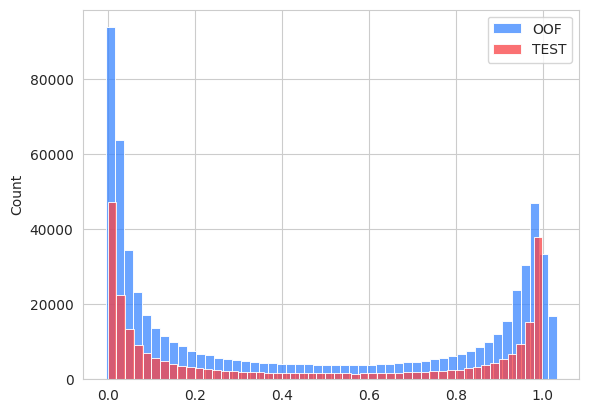

CPU times: user 10h 13min 51s, sys: 37.5 s, total: 10h 14min 28s
Wall time: 2h 35min 37s


In [12]:
%%time
## ======== MLP CV ========
test_mlp, oof_mlp, mlp_score = train_meta(
    clf='mlp',
    oof_df=oof_df,
    pred_df=pred_df,
    features=oof_df.columns,
    y_true=y_true,
    # kf_splits=5,
)
print()

print(oof_mlp.shape, test_mlp.shape)

## -- Distribution Plots --
sns.histplot(oof_mlp, label='OOF', bins=50)
sns.histplot(test_mlp, label='TEST', bins=50)
plt.legend()
plt.show()

# submit[TARGET] = test_mlp
# submit.to_csv(f"submit_mlp_stack_{str(mlp_score).split('.')[1]}.csv", index=False)
# submit.head()

In [13]:
%%time
## -- TRAIN MLP ON FULL DATA --
mlp_clf = MLPRegressor(max_iter=1000, tol=1e-5, random_state=SEED)
mlp_clf.fit(oof_df, y_true)

___ = np.round(roc_auc_score(y_true, mlp_clf.predict(oof_df)), 6)

## -- MAKE SUBMISSION --
n = f"submit_mlp_stackFULL_{str(___).split('.')[1]}.csv"
submit[TARGET] = mlp_clf.predict(pred_df)
submit.to_csv(n, index=False)

print('MLP Submission File Exported -> ', n)
submit.head()

MLP Submission File Exported ->  submit_mlp_stackFULL_955765.csv
CPU times: user 35min 32s, sys: 2.07 s, total: 35min 34s
Wall time: 9min


,id,Heart Disease
0,630000,0.939385
1,630001,0.008633
2,630002,0.983720
3,630003,0.004466
4,630004,0.199754


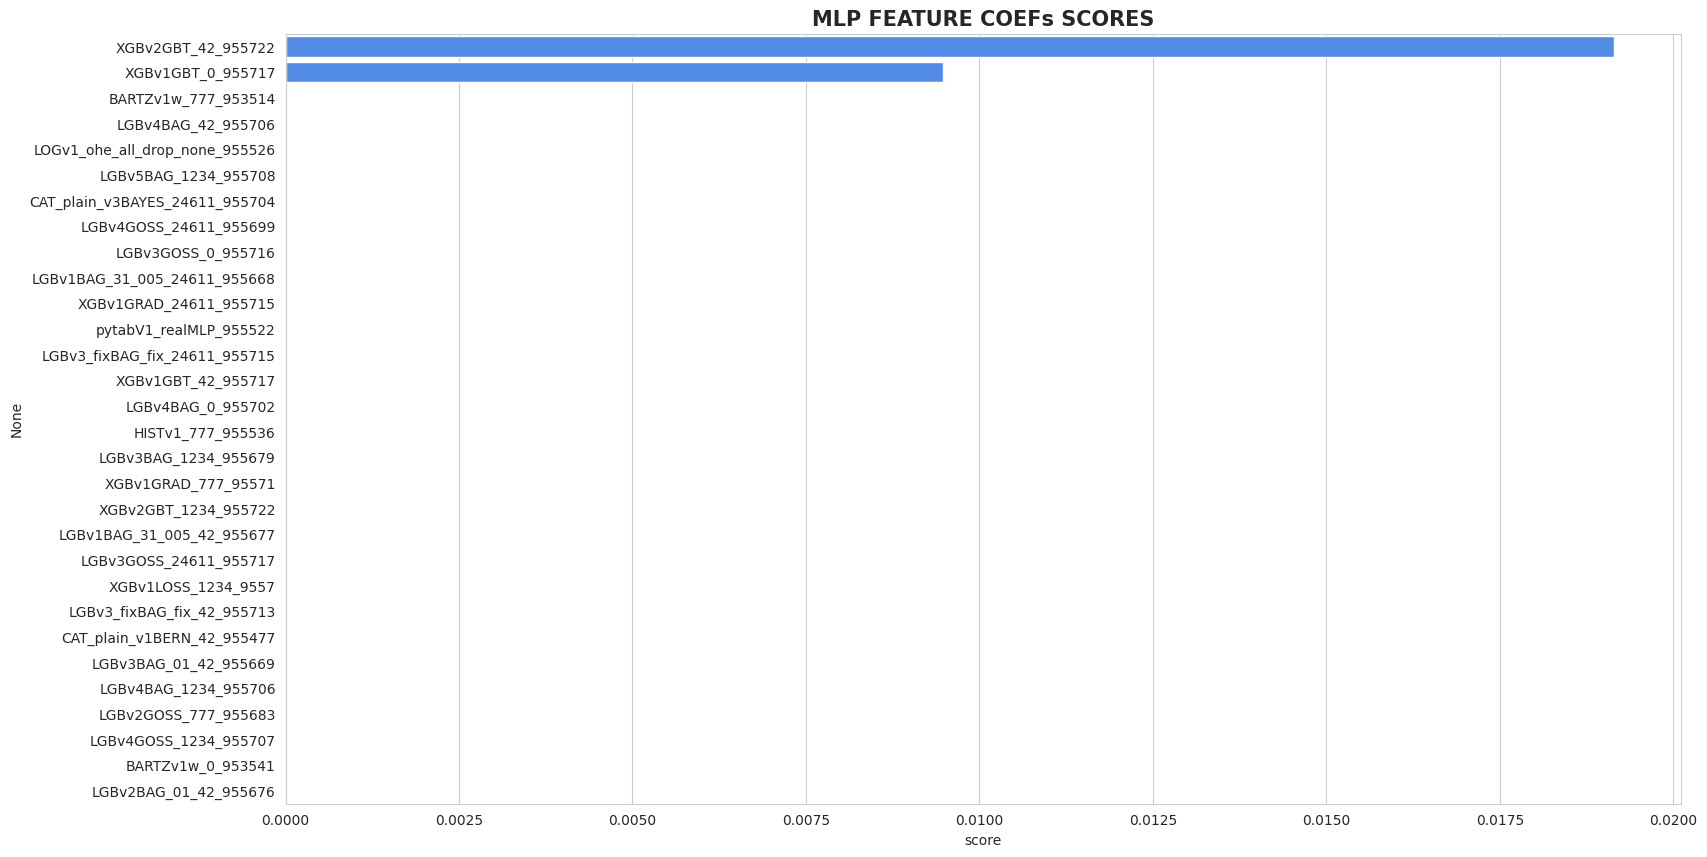

In [14]:
## -- PLOT FEATURE MSE --
mlp_table = pd.DataFrame\
              .from_dict(dict(zip(oof_df.columns, mlp_clf.coefs_[0][0])), orient='index')\
              .rename(columns={0: 'score'}).sort_values('score', ascending=False)

plt.figure(figsize=(18, 10))
sns.barplot(mlp_table[:30], x='score', y=mlp_table[:30].index)
plt.title('MLP FEATURE COEFs SCORES', fontdict={'size': 15, 'weight': 'semibold'})

# plt.tight_layout()
plt.savefig('mlp_oof_coef')
plt.show()

### BAYESIAN

===== BAYESIAN 15 FOLDS =====
Fold 1/15: 0.956301
Fold 2/15: 0.956226
Fold 3/15: 0.956050
Fold 4/15: 0.955709
Fold 5/15: 0.954522
Fold 6/15: 0.954976
Fold 7/15: 0.955937
Fold 8/15: 0.956198
Fold 9/15: 0.955470
Fold 10/15: 0.955144
Fold 11/15: 0.955013
Fold 12/15: 0.956421
Fold 13/15: 0.957068
Fold 14/15: 0.955868
Fold 15/15: 0.956162

✅ STACKING AUC: 0.955794

(630000,) (270000,)


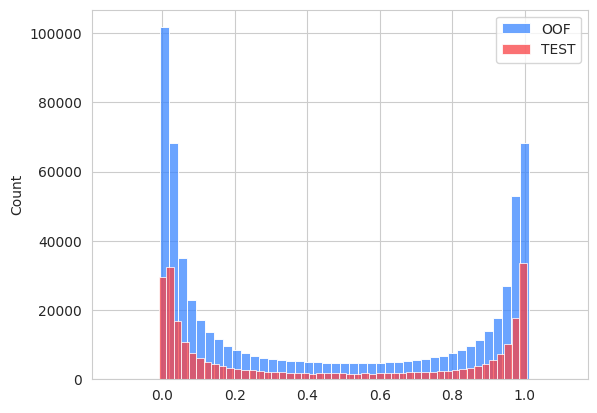

CPU times: user 8min, sys: 14.4 s, total: 8min 14s
Wall time: 2min 28s


In [15]:
%%time

## ======== BAYESIAN CV ========
test_bayes, oof_bayes, bayes_score = train_meta(
    clf='bayes',
    oof_df=oof_df,
    pred_df=pred_df,
    features=oof_df.columns,
    y_true=y_true,
    n_cv=5,
    # kf_splits=5,
)
print()

print(oof_bayes.shape, test_bayes.shape)

## -- Distribution Plots --
sns.histplot(oof_bayes, label='OOF', bins=50)
sns.histplot(test_bayes, label='TEST', bins=50)
plt.legend()
plt.show()

# submit[TARGET] = test_bayes
# submit.to_csv(f"submit_bayes_stack_{str(bayes_score).split('.')[1]}.csv", index=False)
# submit.head()

In [16]:
%%time
## -- TRAIN BAYESIAN ON FULL DATA --
bayes_clf = BayesianRidge(max_iter=1000, tol=1e-5)
bayes_clf.fit(oof_df, y_true)

___ = np.round(roc_auc_score(y_true, bayes_clf.predict(oof_df)), 6)

## -- MAKE SUBMISSION --
n = f"submit_bayes_stackFULL_{str(___).split('.')[1]}.csv"
submit[TARGET] = bayes_clf.predict(pred_df)
submit.to_csv(n, index=False)

print('Bayesian Submission File Exported -> ', n)
submit.head()

Bayesian Submission File Exported ->  submit_bayes_stackFULL_955838.csv
CPU times: user 35 s, sys: 477 ms, total: 35.5 s
Wall time: 10.5 s


,id,Heart Disease
0,630000,0.953322
1,630001,0.004914
2,630002,0.991682
3,630003,0.003161
4,630004,0.196893


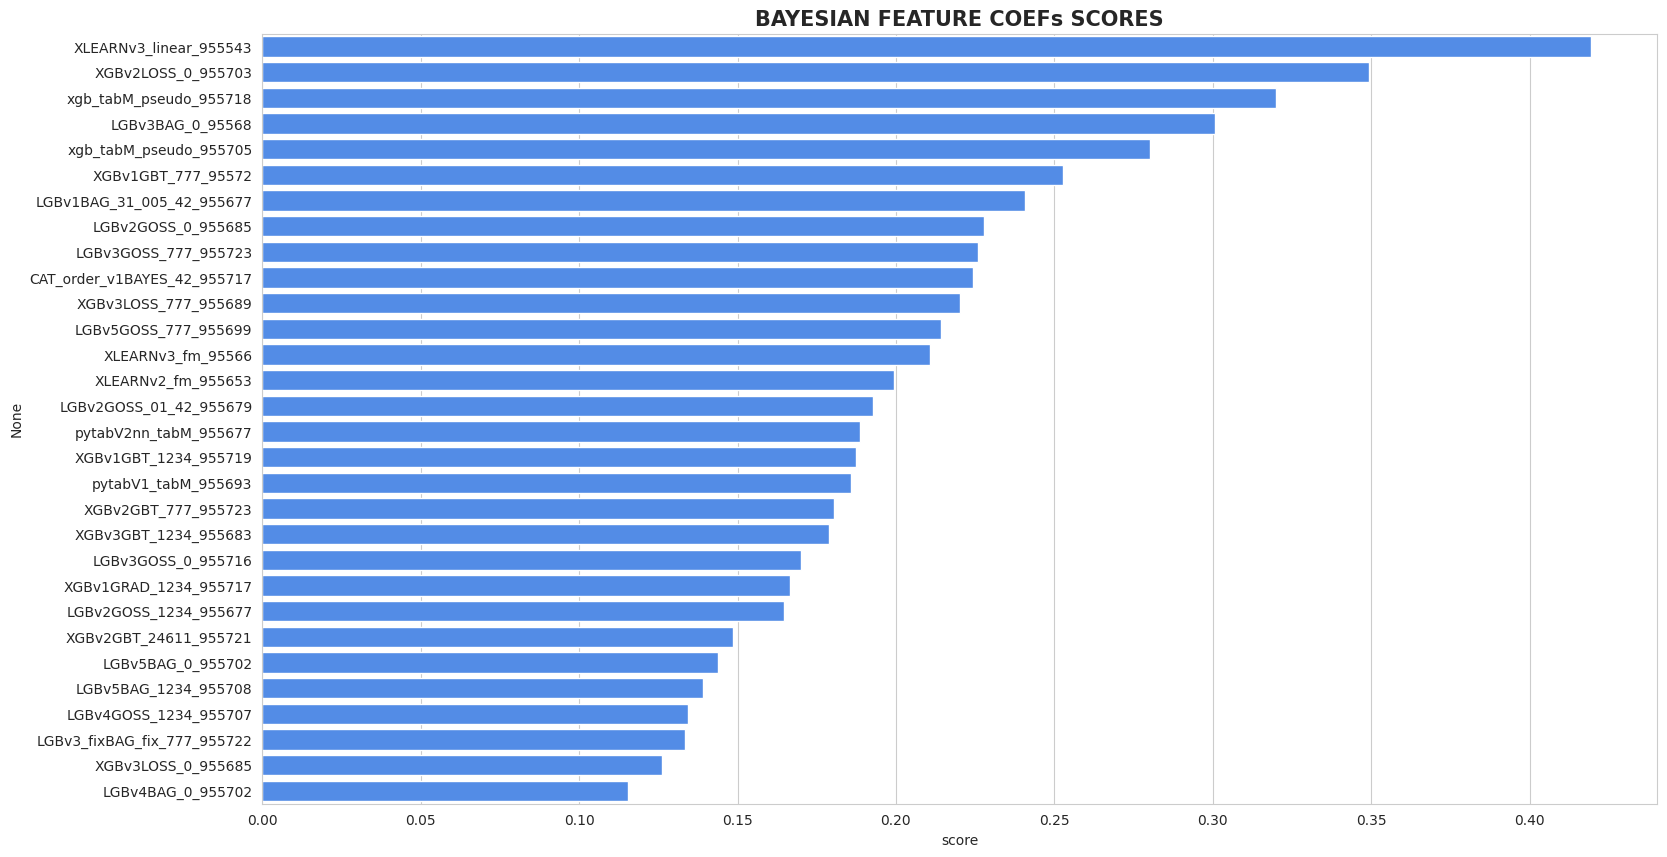

In [17]:
## -- PLOT FEATURE MSE --
bayes_table = pd.DataFrame\
                .from_dict(dict(zip(oof_df.columns, bayes_clf.coef_)), orient='index')\
                .rename(columns={0: 'score'}).sort_values('score', ascending=False)

plt.figure(figsize=(18, 10))
sns.barplot(bayes_table[:30], x='score', y=bayes_table[:30].index)
plt.title('BAYESIAN FEATURE COEFs SCORES', fontdict={'size': 15, 'weight': 'semibold'})
# plt.tight_layout()
plt.savefig('bayes_oof_coef')
plt.show()

### ELASTIC NET

===== ELASTIC NET 15 FOLDS =====
Fold 1/15: 0.956328 | Best Alpha: 0.0003
Fold 2/15: 0.956211 | Best Alpha: 0.0003
Fold 3/15: 0.956030 | Best Alpha: 0.0003
Fold 4/15: 0.955675 | Best Alpha: 0.0003
Fold 5/15: 0.954472 | Best Alpha: 0.0003
Fold 6/15: 0.954984 | Best Alpha: 0.0003
Fold 7/15: 0.955959 | Best Alpha: 0.0003
Fold 8/15: 0.956195 | Best Alpha: 0.0003
Fold 9/15: 0.955483 | Best Alpha: 0.0003
Fold 10/15: 0.955117 | Best Alpha: 0.0003
Fold 11/15: 0.954994 | Best Alpha: 0.0003
Fold 12/15: 0.956388 | Best Alpha: 0.0003
Fold 13/15: 0.957048 | Best Alpha: 0.0003
Fold 14/15: 0.955877 | Best Alpha: 0.0003
Fold 15/15: 0.956130 | Best Alpha: 0.0003

✅ STACKING AUC: 0.955773

(630000,) (270000,)


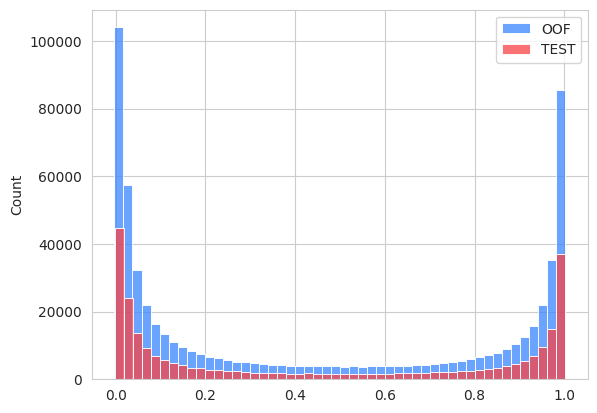

CPU times: user 1h 21min 49s, sys: 49.5 s, total: 1h 22min 38s
Wall time: 21min 34s


In [18]:
%%time
## ======== ELASTIC NET CV ========
test_elastic, oof_elastic, elastic_score = train_meta(
    clf='elastic',
    oof_df=oof_df,
    pred_df=pred_df,
    features=oof_df.columns,
    y_true=y_true,
    n_cv=5,
    # kf_splits=5,
    # n_alphas=np.logspace(-3, 3, 50),
)
print()

print(oof_elastic.shape, test_elastic.shape)

## -- Distribution Plots --
sns.histplot(oof_elastic, label='OOF', bins=50)
sns.histplot(test_elastic, label='TEST', bins=50)
plt.legend()
plt.show()

# submit[TARGET] = test_elastic
# submit.to_csv(f"submit_elastic_stack_{str(elastic_score).split('.')[1]}.csv", index=False)
# submit.head()

In [19]:
%%time
## -- TRAIN ELASTIC ON FULL DATA --
elastic_clf = ElasticNetCV(cv=5, tol=1e-5, n_jobs=os.cpu_count(), random_state=SEED)
elastic_clf.fit(oof_df, y_true)

___ = np.round(roc_auc_score(y_true, elastic_clf.predict(oof_df)), 6)

## -- MAKE SUBMISSION --
n = f"submit_elastic_stackFULL_{str(___).split('.')[1]}.csv"
submit[TARGET] = elastic_clf.predict(pred_df)
submit.to_csv(n, index=False)

print('Elastic Submission File Exported -> ', n)
submit.head()

Elastic Submission File Exported ->  submit_elastic_stackFULL_955778.csv
CPU times: user 5min 59s, sys: 2.9 s, total: 6min 1s
Wall time: 1min 34s


,id,Heart Disease
0,630000,0.953392
1,630001,0.006182
2,630002,0.992762
3,630003,0.002528
4,630004,0.198798


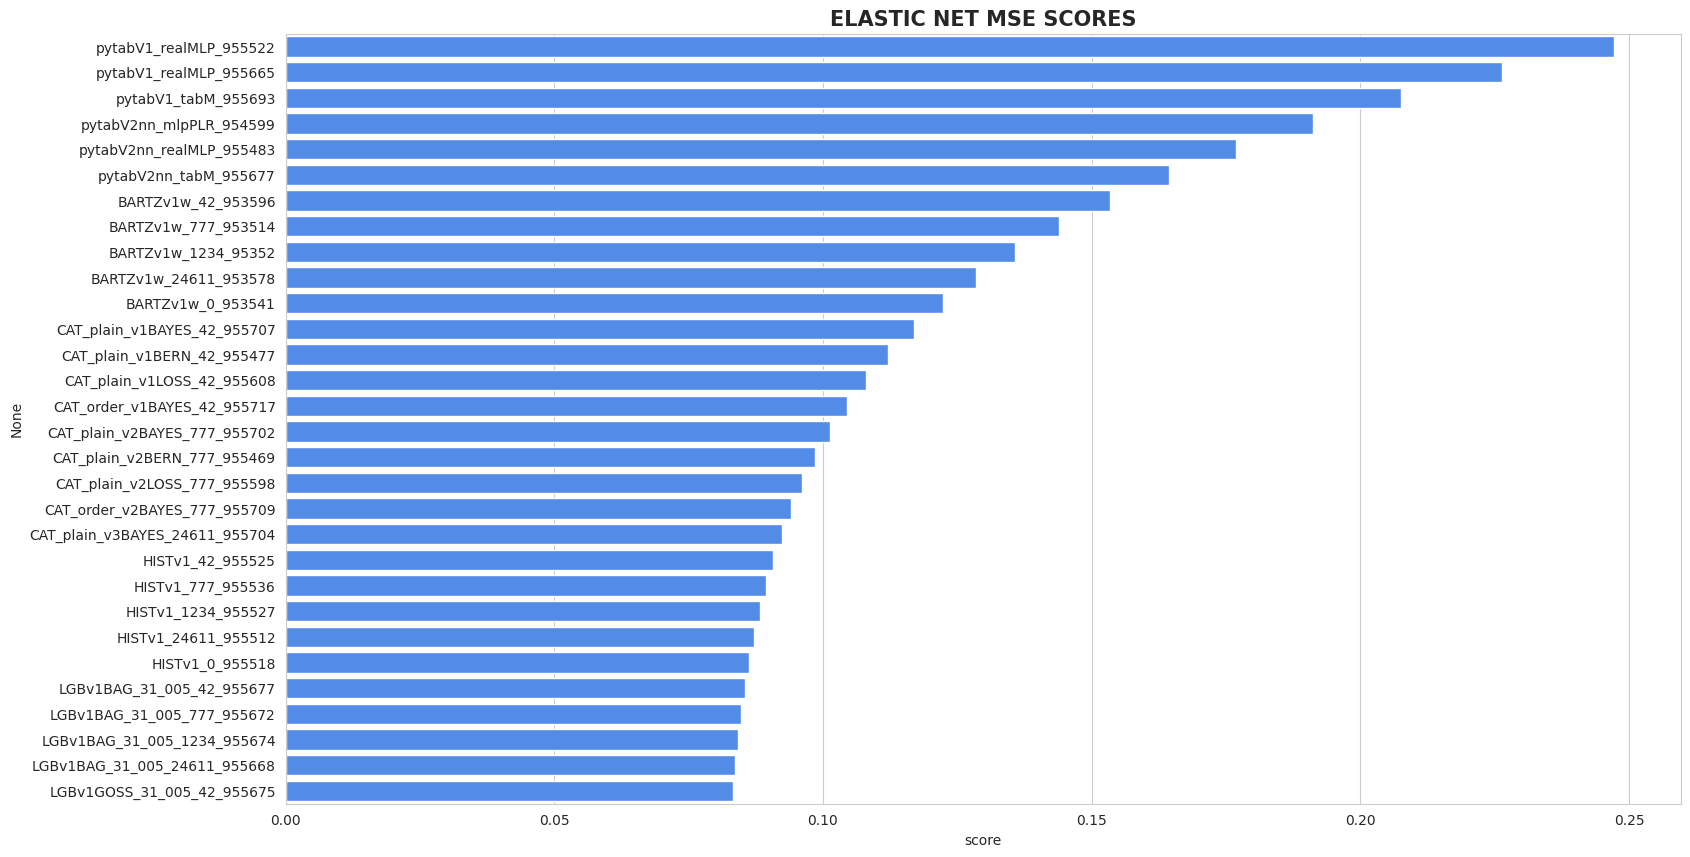

In [20]:
## -- PLOT FEATURE MSE --
elastic_table = pd.DataFrame\
                .from_dict(dict(zip(oof_df.columns, elastic_clf.mse_path_)), orient='index')\
                .rename(columns={0: 'score'}).sort_values('score', ascending=False)

plt.figure(figsize=(18, 10))
sns.barplot(elastic_table[:30], x='score', y=elastic_table[:30].index)
plt.title('ELASTIC NET MSE SCORES', fontdict={'size': 15, 'weight': 'semibold'})
# plt.tight_layout()
plt.savefig('elastic_oof_coef')
plt.show()

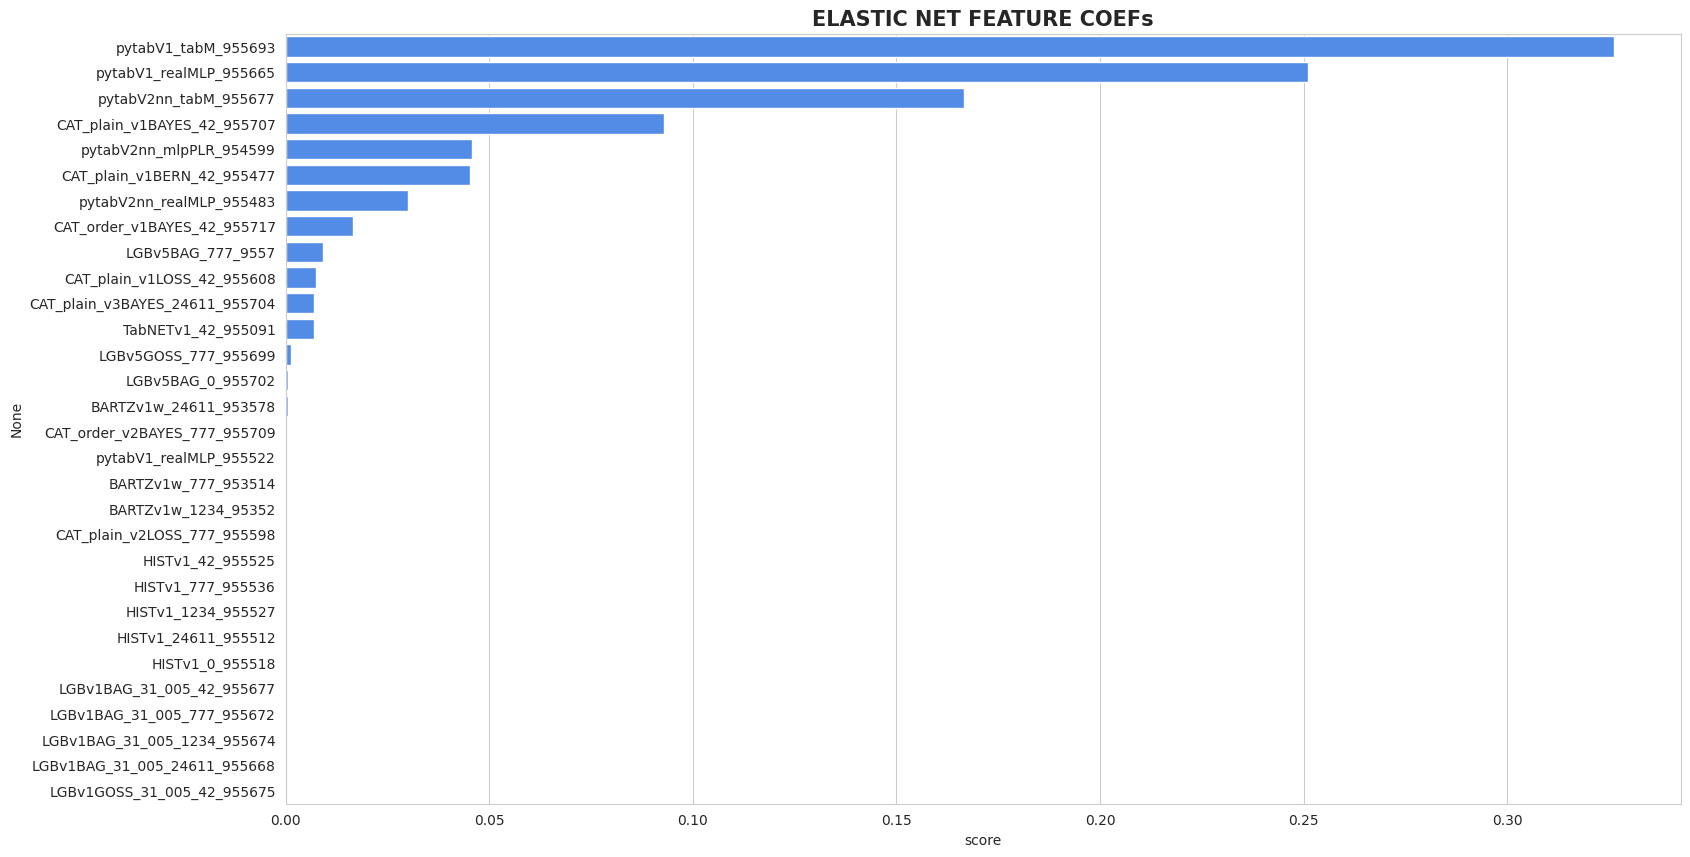

In [21]:
## -- PLOT FEATURE COEFS --
elastic_table = pd.DataFrame\
                .from_dict(dict(zip(oof_df.columns, elastic_clf.coef_)), orient='index')\
                .rename(columns={0: 'score'}).sort_values('score', ascending=False)

plt.figure(figsize=(18, 10))
sns.barplot(elastic_table[:30], x='score', y=elastic_table[:30].index)
plt.title('ELASTIC NET FEATURE COEFs', fontdict={'size': 15, 'weight': 'semibold'})

# plt.tight_layout()
plt.savefig('elastic_oof_coef')
plt.show()

In [22]:
elastic_features = elastic_table[elastic_table.values > 0].index.tolist()
elastic_features

['pytabV1_tabM_955693',
 'pytabV1_realMLP_955665',
 'pytabV2nn_tabM_955677',
 'CAT_plain_v1BAYES_42_955707',
 'pytabV2nn_mlpPLR_954599',
 'CAT_plain_v1BERN_42_955477',
 'pytabV2nn_realMLP_955483',
 'CAT_order_v1BAYES_42_955717',
 'LGBv5BAG_777_9557',
 'CAT_plain_v1LOSS_42_955608',
 'CAT_plain_v3BAYES_24611_955704',
 'TabNETv1_42_955091',
 'LGBv5GOSS_777_955699',
 'LGBv5BAG_0_955702',
 'BARTZv1w_24611_953578',
 'CAT_order_v2BAYES_777_955709']

### LASSO

===== LASSO 15 FOLDS =====
Fold 1/15: 0.956311 | Best Alpha: 0.0002
Fold 2/15: 0.956209 | Best Alpha: 0.0002
Fold 3/15: 0.956010 | Best Alpha: 0.0002
Fold 4/15: 0.955648 | Best Alpha: 0.0002
Fold 5/15: 0.954448 | Best Alpha: 0.0002
Fold 6/15: 0.954958 | Best Alpha: 0.0002
Fold 7/15: 0.955946 | Best Alpha: 0.0002
Fold 8/15: 0.956207 | Best Alpha: 0.0002
Fold 9/15: 0.955472 | Best Alpha: 0.0002
Fold 10/15: 0.955112 | Best Alpha: 0.0002
Fold 11/15: 0.954990 | Best Alpha: 0.0002
Fold 12/15: 0.956371 | Best Alpha: 0.0002
Fold 13/15: 0.957031 | Best Alpha: 0.0002
Fold 14/15: 0.955856 | Best Alpha: 0.0002
Fold 15/15: 0.956087 | Best Alpha: 0.0002

✅ STACKING AUC: 0.955756

(630000,) (270000,)


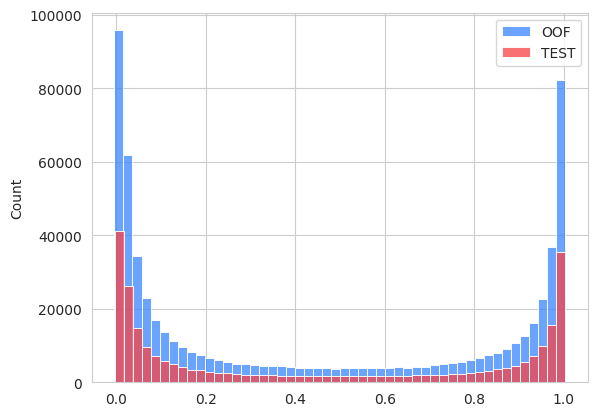

CPU times: user 1h 20min 54s, sys: 49.6 s, total: 1h 21min 44s
Wall time: 21min 35s


In [23]:
%%time

## ======== LASSO CV ========
test_lasso, oof_lasso, lasso_score = train_meta(
    clf='lasso',
    oof_df=oof_df,
    pred_df=pred_df,
    features=oof_df.columns,
    y_true=y_true,
    n_cv=5,
    # kf_splits=5,
    # n_alphas=np.logspace(-3, 3, 50),
)
print()

print(oof_lasso.shape, test_lasso.shape)

## -- Distribution Plots --
sns.histplot(oof_lasso, label='OOF', bins=50)
sns.histplot(test_lasso, label='TEST', bins=50)
plt.legend()
plt.show()

# submit[TARGET] = test_lasso
# submit.to_csv(f"submit_ridge_stackCV_{str(lasso_score).split('.')[1]}.csv", index=False)
# submit.head()

In [24]:
%%time
## -- TRAIN LASSO ON FULL DATA --
lasso_clf = LassoCV(cv=5, tol=1e-5, n_jobs=os.cpu_count(), random_state=SEED)
lasso_clf.fit(oof_df, y_true)

___ = np.round(roc_auc_score(y_true, lasso_clf.predict(oof_df)), 6)

## -- MAKE SUBMISSION --
n = f"submit_lasso_stackFULL_{str(___).split('.')[1]}.csv"
submit[TARGET] = lasso_clf.predict(pred_df)
submit.to_csv(n, index=False)

print('Lasso Submission File Exported -> ', n)
submit.head()

Lasso Submission File Exported ->  submit_lasso_stackFULL_955762.csv
CPU times: user 5min, sys: 2.79 s, total: 5min 3s
Wall time: 1min 19s


,id,Heart Disease
0,630000,0.953985
1,630001,0.006846
2,630002,0.993004
3,630003,0.002506
4,630004,0.198292


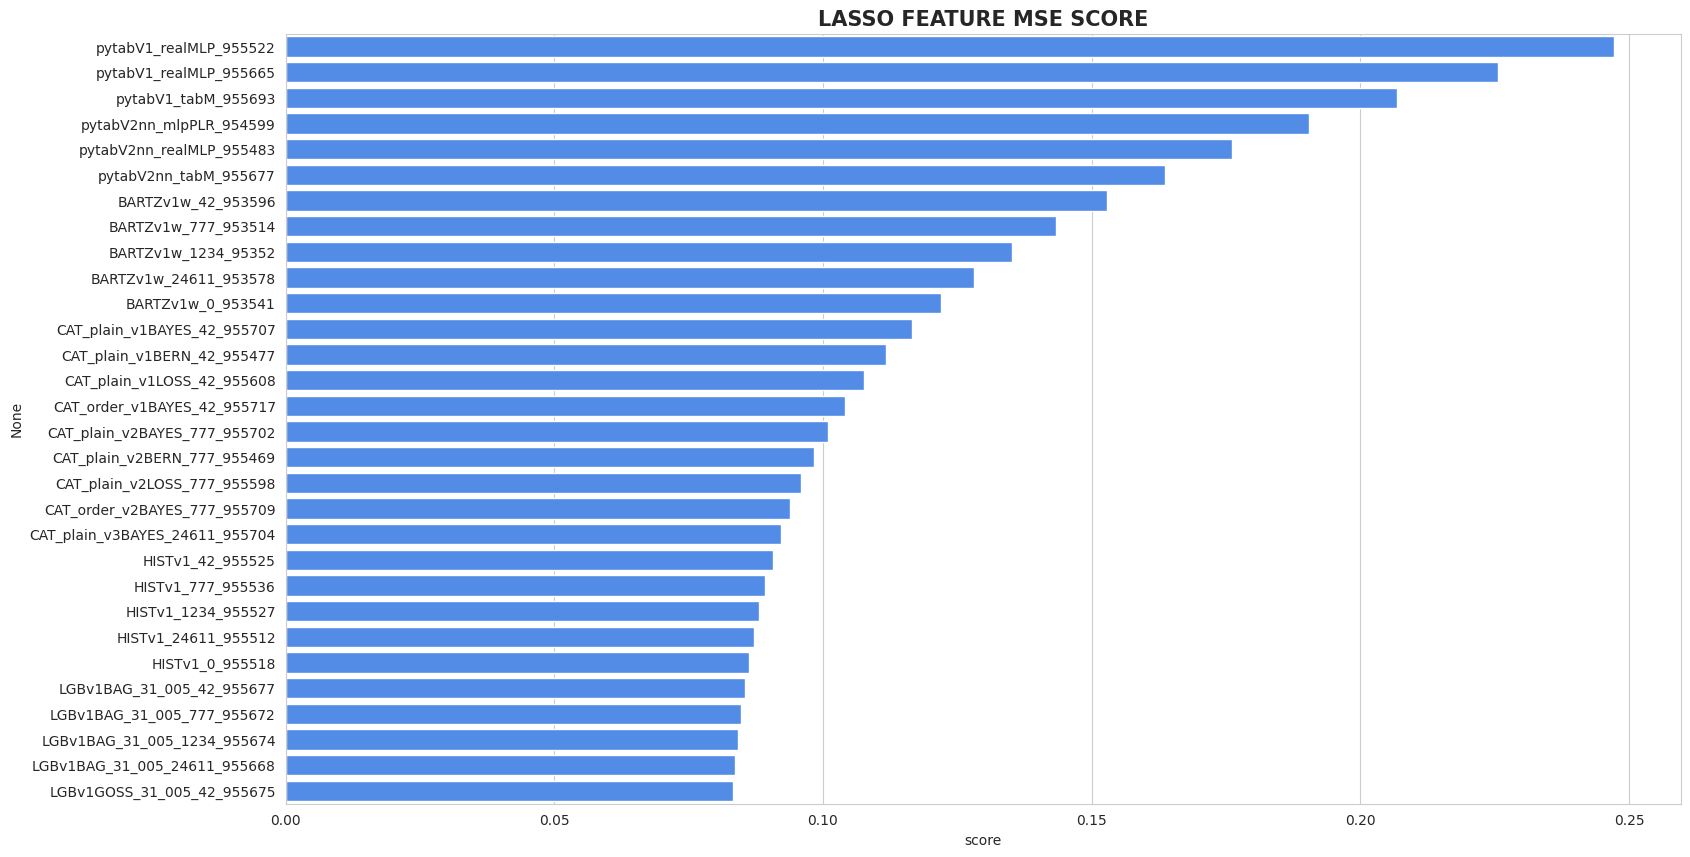

In [25]:
## -- PLOT FEATURE MSE --
lasso_table = pd.DataFrame\
                .from_dict(dict(zip(oof_df.columns, lasso_clf.mse_path_)), orient='index')\
                .rename(columns={0: 'score'}).sort_values('score', ascending=False)

plt.figure(figsize=(18, 10))
sns.barplot(lasso_table[:30], x='score', y=lasso_table[:30].index)
plt.title('LASSO FEATURE MSE SCORE', fontdict={'size': 15, 'weight': 'semibold'})
# plt.tight_layout()

plt.savefig('lasso_oof_coef')
plt.show()

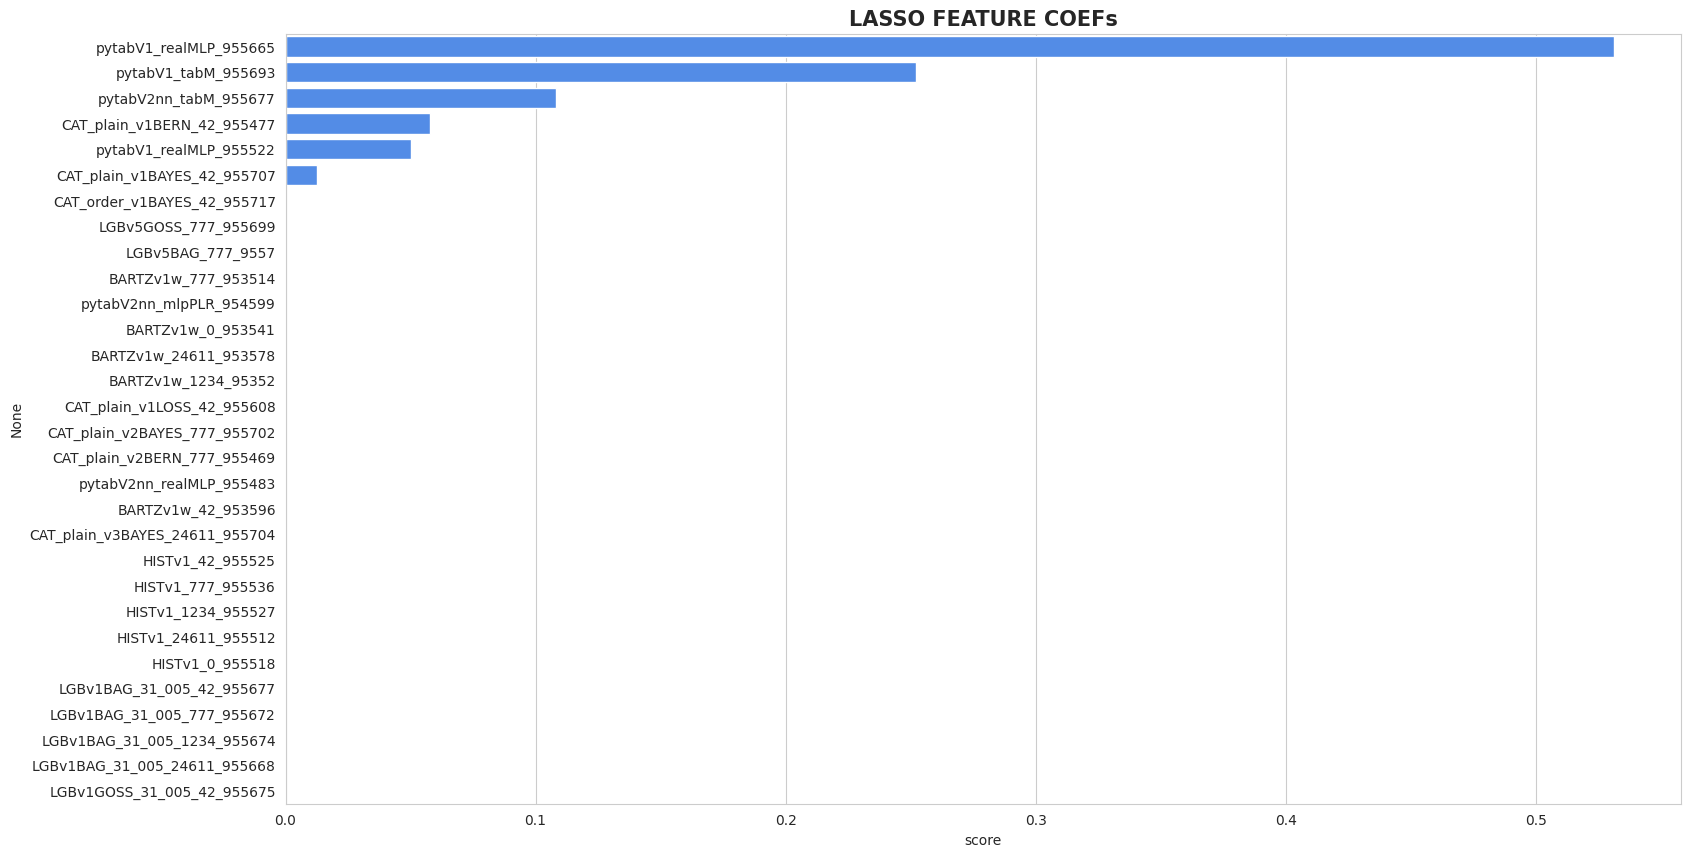

In [26]:
## -- PLOT FEATURE COEFS --
lasso_table = pd.DataFrame\
                .from_dict(dict(zip(oof_df.columns, lasso_clf.coef_)), orient='index')\
                .rename(columns={0: 'score'}).sort_values('score', ascending=False)

plt.figure(figsize=(18, 10))
sns.barplot(lasso_table[:30], x='score', y=lasso_table[:30].index)
plt.title('LASSO FEATURE COEFs', fontdict={'size': 15, 'weight': 'semibold'})

# plt.tight_layout()
plt.savefig('lasso_oof_coef')
plt.show()

In [27]:
lasso_features = lasso_table[lasso_table.values > 0].index.tolist()
lasso_features

['pytabV1_realMLP_955665',
 'pytabV1_tabM_955693',
 'pytabV2nn_tabM_955677',
 'CAT_plain_v1BERN_42_955477',
 'pytabV1_realMLP_955522',
 'CAT_plain_v1BAYES_42_955707',
 'CAT_order_v1BAYES_42_955717',
 'LGBv5GOSS_777_955699',
 'LGBv5BAG_777_9557']

### RIDGE

===== RIDGE 15 FOLDS =====
Fold 1/15: 0.956311 | Best Alpha: 10.0000
Fold 2/15: 0.956231 | Best Alpha: 10.0000
Fold 3/15: 0.956056 | Best Alpha: 10.0000
Fold 4/15: 0.955720 | Best Alpha: 10.0000
Fold 5/15: 0.954519 | Best Alpha: 10.0000
Fold 6/15: 0.954976 | Best Alpha: 10.0000
Fold 7/15: 0.955961 | Best Alpha: 10.0000
Fold 8/15: 0.956211 | Best Alpha: 10.0000
Fold 9/15: 0.955481 | Best Alpha: 10.0000
Fold 10/15: 0.955138 | Best Alpha: 10.0000
Fold 11/15: 0.955014 | Best Alpha: 10.0000
Fold 12/15: 0.956414 | Best Alpha: 10.0000
Fold 13/15: 0.957065 | Best Alpha: 10.0000
Fold 14/15: 0.955873 | Best Alpha: 10.0000
Fold 15/15: 0.956152 | Best Alpha: 10.0000

✅ STACKING AUC: 0.955798

(630000,) (270000,)


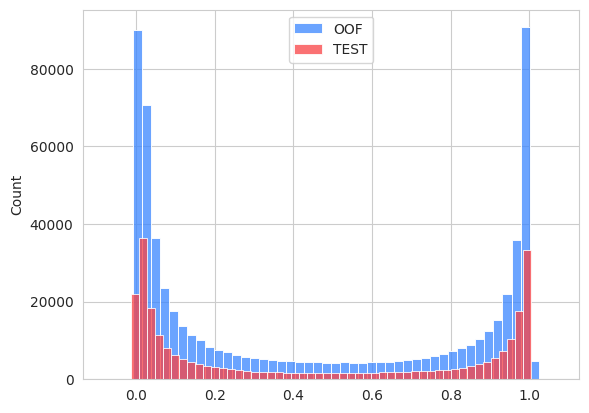

CPU times: user 8min 51s, sys: 1min 1s, total: 9min 52s
Wall time: 4min 25s


In [28]:
%%time
## ======== RIDGE CV ========
test_ridge, oof_ridge, ridge_score = train_meta(
    # clf='lasso',
    oof_df=oof_df,
    pred_df=pred_df,
    features=oof_df.columns,
    y_true=y_true,
    n_cv=5,
    # kf_splits=5,
    # n_alphas=(1.0, 10.0, 100.0, 1000.0),
)
print()

print(oof_ridge.shape, test_ridge.shape)

## -- Distribution Plots --
# sns.histplot(y_true, label='True', bins=80)
sns.histplot(oof_ridge, label='OOF', bins=50)
sns.histplot(test_ridge, label='TEST', bins=50)
plt.legend()
plt.show()

# submit[TARGET] = test_ridge
# submit.to_csv(f"submit_ridge_stack_{str(ridge_score).split('.')[1]}.csv", index=False)
# submit.head()

In [29]:
%%time
## -- TRAIN ON FULL DATA --
ridge_clf = RidgeCV(scoring='neg_mean_squared_error', cv=5)
ridge_clf.fit(oof_df, y_true)

___ = np.round(roc_auc_score(y_true, ridge_clf.predict(oof_df)), 6)

## -- MAKE SUBMISSION --
n = f"submit_ridge_stackFULL_{str(___).split('.')[1]}.csv"
submit[TARGET] = ridge_clf.predict(pred_df)
submit.to_csv(n, index=False)

print('Ridge Submission File Exported -> ', n)
submit.head()

Ridge Submission File Exported ->  submit_ridge_stackFULL_955827.csv
CPU times: user 38.1 s, sys: 3.83 s, total: 42 s
Wall time: 18.5 s


,id,Heart Disease
0,630000,0.952654
1,630001,0.005146
2,630002,0.991777
3,630003,0.003102
4,630004,0.196680


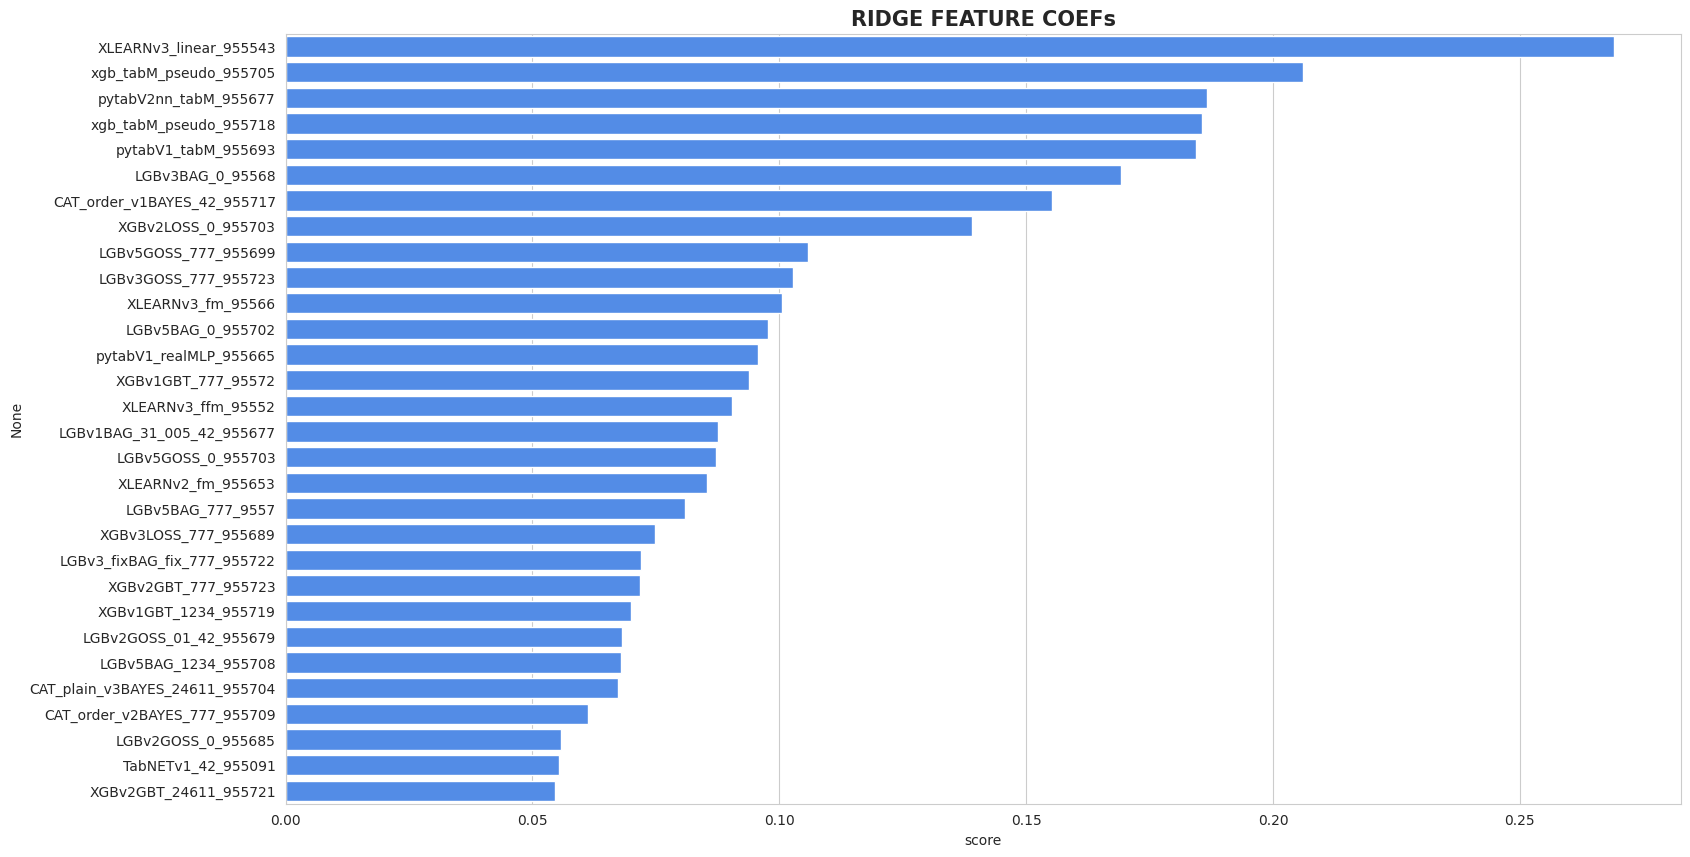

In [30]:
ridge_table = pd.DataFrame\
                .from_dict(dict(zip(oof_df.columns, ridge_clf.coef_)), orient='index')\
                .rename(columns={0: 'score'}).sort_values('score', ascending=False)

plt.figure(figsize=(18, 10))
sns.barplot(ridge_table[:30], x='score', y=ridge_table[:30].index)
plt.title('RIDGE FEATURE COEFs', fontdict={'size': 15, 'weight': 'semibold'})
# plt.tight_layout()

plt.savefig('ridge_oof_coef')
plt.show()

In [31]:
ridge_features = ridge_table[ridge_table.values > 0].index.tolist()
print('Total top features by Ridge:', len(ridge_features))

Total top features by Ridge: 72


In [32]:
# %%time

# ## -- CALIBRATION FIT --
# VAC_clf = VennAbersCalibrator(estimator=clf, inductive=False, n_splits=5)
# VAC_clf.fit(oof_df, y_true)

# clf_score = np.round(roc_auc_score(y_true, VAC_clf.predict(oof_df)), 6)
# clf_score

In [33]:
# ## -- MAKE SUBMISSION --
# predictions_CVAP = VAC_clf.predict(pred_df)

# submit[TARGET] = predictions_CVAP
# submit.to_csv(f"submit_venn_calib_{str(clf_score).split('.')[1]}.csv", index=False)
# submit.head()

## ENSEMBLE 2: HILL CLIMBING

In [34]:
try:
    from hillclimbers import climb_hill, partial
except:
    %pip install -qq hillclimbers
    from hillclimbers import climb_hill, partial

  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [35]:
%%time
test_hillclimb, oof_hillclimb= climb_hill(
                               train = train,
                              target = TARGET,
                         oof_pred_df = oof_df[ridge_features],
                        test_pred_df = pred_df[ridge_features],
                           objective = 'maximize',
                         eval_metric = partial(roc_auc_score),
                    # negative_weights = True,
                    return_oof_preds = True,
                           precision = 0.01,
                           plot_hill = True,
                           plot_hist = False,
    )

# 0.957941

   /\  
  /__\  hillclimbers 
 /    \
/______\ 

Models to be ensembled | (72 total): 

LGBv3GOSS_777_955723:           0.95572 (best solo model)
XGBv2GBT_777_955723:            0.95572
XGBv2GRAD_777_955722:           0.95572
XGBv2GBT_0_955722:              0.95572
LGBv3_fixBAG_fix_777_955722:    0.95572
XGBv2GBT_1234_955722:           0.95572
XGBv2GBT_42_955722:             0.95572
XGBv2GBT_24611_955721:          0.95572
XGBv1GBT_777_95572:             0.95572
XGBv1GBT_24611_955719:          0.95572
XGBv1GBT_1234_955719:           0.95572
xgb_tabM_pseudo_955718:         0.95572
LGBv3GOSS_24611_955717:         0.95572
CAT_order_v1BAYES_42_955717:    0.95572
XGBv1GRAD_1234_955717:          0.95572
XGBv1GRAD_0_955717:             0.95572
XGBv1GBT_42_955717:             0.95572
LGBv3GOSS_0_955716:             0.95572
LGBv3GOSS_1234_955714:          0.95571
CAT_order_v2BAYES_777_955709:   0.95571
LGBv5BAG_1234_955708:           0.95571
CAT_plain_v1BAYES_42_955707:    0.95571
LGBv4GOSS_1234

CPU times: user 2h 13min 21s, sys: 17.2 s, total: 2h 13min 39s
Wall time: 2h 13min 58s


In [36]:
hillclimb_score = np.round(roc_auc_score(y_true, oof_hillclimb), 6)

print(f"-> Hillclimb Score: {hillclimb_score}")
print(f"""\n
-> TRUE Avg.: {np.mean(y_true):.5f}
-> OOFS Avg.: {np.mean(oof_hillclimb):.5f}
-> TEST Avg.: {np.mean(test_hillclimb):.5f}
    """)

## -- SUBMISSION FILE --
n = f"submit_hillclimb_{str(hillclimb_score).split('.')[1]}.csv"
submit[TARGET] = test_hillclimb
submit.to_csv(n, index=False)

print('Hillclimb Submission File Exported -> ', n)
submit.head()

-> Hillclimb Score: 0.955794


-> TRUE Avg.: 0.44834
-> OOFS Avg.: 0.44843
-> TEST Avg.: 0.44996
    
Hillclimb Submission File Exported ->  submit_hillclimb_955794.csv


,id,Heart Disease
0,630000,0.948311
1,630001,0.007986
2,630002,0.991300
3,630003,0.004344
4,630004,0.198884


## ENSEMBLE 3: OPTIMIZED BLENDING WITH SCIPY

In [37]:
from scipy.optimize import minimize
# np.random.seed(SEED)

In [38]:
columns = [
    'ridge_'+str(ridge_score).split('.')[1],
    'lasso_'+str(lasso_score).split('.')[1],
    'elastic_'+str(elastic_score).split('.')[1],
    'bayes_'+str(bayes_score).split('.')[1],
    'mlp_'+str(mlp_score).split('.')[1],
    'hill_'+str(hillclimb_score).split('.')[1],
]
oof_predictions = [
    oof_ridge,
    oof_lasso,
    oof_elastic,
    oof_bayes,
    oof_mlp,
    oof_hillclimb,
]
test_predictions = [
    test_ridge,
    test_lasso,
    test_elastic,
    test_bayes,
    test_mlp,
    test_hillclimb,
]

train_final = pd.DataFrame(dict(zip(columns, oof_predictions)))
test_final  = pd.DataFrame(dict(zip(columns, test_predictions)))

train_final.shape, test_final.shape

((630000, 6), (270000, 6))

In [39]:
display(train_final.head())
print()
display(test_final .head())

,ridge_955798,lasso_955756,elastic_955773,bayes_955794,mlp_955204,hill_955794
0,0.998115,0.999350,0.998879,0.997904,0.990957,0.997677
1,0.007919,0.009123,0.009005,0.007279,0.010307,0.009992
2,0.006116,0.006895,0.006307,0.006233,0.009713,0.008749
3,0.049981,0.044288,0.045098,0.050190,0.051589,0.051006
4,0.997100,0.999192,0.998827,0.997402,0.992225,0.997607


,ridge_955798,lasso_955756,elastic_955773,bayes_955794,mlp_955204,hill_955794
0,0.952604,0.953975,0.953378,0.953296,0.945057,0.948311
1,0.005159,0.006844,0.006193,0.004916,0.005850,0.007986
2,0.991782,0.993001,0.992771,0.991680,0.990081,0.991300
3,0.003098,0.002503,0.002526,0.003152,0.002178,0.004344
4,0.196699,0.198278,0.198852,0.196905,0.196904,0.198884


In [40]:
blend_train = []
blend_test = []

for col in train_final:
    blend_train.append(train_final[col])
blend_train = np.array(blend_train)

for col in test_final:
    blend_test.append(test_final[col])
blend_test = np.array(blend_test)

print(len(blend_train), len(blend_test))

a = 0.12345
print("{0:.2f}".format(a))

6 6
0.12


In [41]:
## -- BLOCK 2 - AUC-based objective and optimization
def roc_min_func(weights):
    final_prediction = np.tensordot(weights, blend_train, axes=(0, 0))
    return roc_auc_score(y_true, final_prediction)
    
print('\n Finding Blending Weights (AUC objective) *****\n')
res_list = []
weights_list = []

n_models = blend_train.shape[0]

for k in range(100):  # -> Optimization rounds
    starting_values = np.random.uniform(size=n_models)
    bounds = [(0, 1)] * n_models

    res = minimize(
        roc_min_func,
        starting_values,
        method='L-BFGS-B',
        bounds=bounds,
        options={'disp': False, 'maxiter': 100000},
    )

    res_list.append(res['fun'])
    weights_list.append(res['x'])

    res_fun = format(res['fun'], '.6f')
    items = [format(item, '.6f') for item in res['x']]

    print(
        '{iter}\tScore: {score}\tWeights: {weights}'.format(
            iter=(k + 1),
            score=res_fun,
            weights=' | '.join([str(item) for item in items]),
        )
    )

bestAUC = np.max(res_list)  # -> AUC: higher is better
bestWght = weights_list[int(np.argmax(res_list))]
weights = bestWght

blend_score = round(bestAUC, 6)


 Finding Blending Weights (AUC objective) *****

1	Score: 0.955798	Weights: 0.530177 | 0.512641 | 0.722681 | 0.531483 | 0.052159 | 0.782010
2	Score: 0.955741	Weights: 0.786386 | 0.013807 | 0.814532 | 0.775713 | 0.942182 | 0.843053
3	Score: 0.955742	Weights: 0.477487 | 0.515248 | 0.810465 | 0.975392 | 0.983363 | 0.664056
4	Score: 0.955743	Weights: 0.814974 | 0.141450 | 0.043385 | 0.192373 | 0.570890 | 0.860388
5	Score: 0.955778	Weights: 0.782490 | 0.879666 | 0.212120 | 0.059393 | 0.275668 | 0.416116
6	Score: 0.955795	Weights: 0.855813 | 0.941816 | 0.395563 | 0.163500 | 0.053435 | 0.742954
7	Score: 0.955735	Weights: 0.660230 | 0.811927 | 0.632725 | 0.505298 | 0.882111 | 0.283153
8	Score: 0.955768	Weights: 0.107582 | 0.058243 | 0.649974 | 0.109827 | 0.233145 | 0.578907
9	Score: 0.955793	Weights: 0.657657 | 0.817977 | 0.831307 | 0.208160 | 0.080230 | 0.832154
10	Score: 0.955753	Weights: 0.064817 | 0.818455 | 0.774931 | 0.498963 | 0.681568 | 0.956289
11	Score: 0.955773	Weights: 0.940372 | 

Ensemble AUC: 0.955803

 ----------------
 Weights  | Model
 ----------------
 0.881328 * model-1
 0.114298 * model-2
 0.309900 * model-3
 0.608519 * model-4
 0.052284 * model-5
 0.795601 * model-6



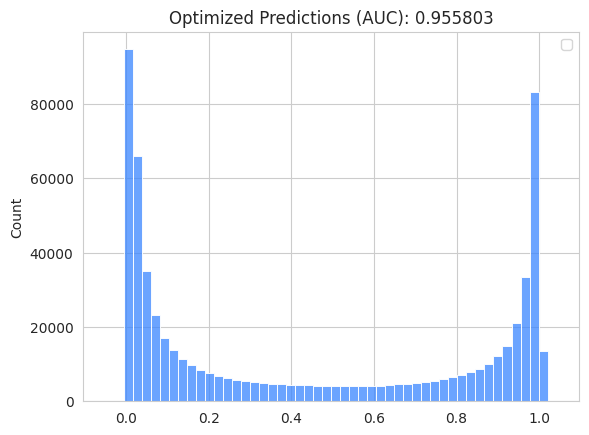

In [42]:
# BLOCK 3 - reporting and final model
print(f'Ensemble AUC: {blend_score}')
# print('\n Best Weights: {weights}'.format(weights=bestWght))

train_prices = np.zeros(len(blend_train[0]))
test_prices  = np.zeros(len(blend_test[0]))

print('\n ----------------')
print(' Weights  | Model')
print(' ----------------')
for k in range(len(blend_test)):
    print(' %.6f * model-%d' % (weights[k], (k + 1)))
    test_prices += blend_test[k] * weights[k]

for k in range(len(blend_train)):
    train_prices += blend_train[k] * weights[k]

# Optional: normalize weights to sum to 1 (same as before)
bestWght /= np.sum(bestWght)
print()

# BLOCK 4 - optional visualization (unchanged logic)
optimized_oof = np.tensordot(bestWght, train_final, axes=((0), (1)))  # shape (n_samples,)
sns.histplot(optimized_oof, bins=50)
plt.title(f"Optimized Predictions (AUC): {blend_score}")
plt.legend()
plt.show()

In [43]:
## -- APPLY WEIGHTS TO TEST PREDICTIONS --
optimized_test = test_final.to_numpy().dot(weights)
submit[TARGET] = optimized_test
submit.to_csv(f"submit_Optimized_Blend_{str(blend_score).split('.')[1]}.csv", index=False)
submit.head()

,id,Heart Disease
0,630000,0.951521
1,630001,0.006119
2,630002,0.991750
3,630003,0.003362
4,630004,0.197685
